# Bézier Curve

## Bernstein Polynomial Form

In [8]:
import torch
import math
import matplotlib.pyplot as plt

In [9]:
control_points = torch.tensor([
    [0.0, 0.0],
    [2.0, 4.0],
    [4.0, 3.0],
    [6.0, 0.0]
])

It starts exactly at $P_0$ and ends exactly at $P_3$. The intermediate points $P_1$ and $P_2$ determine the tangents. Specifically, the line segment $(P_1 - P_0)$ defines the initial direction, and $(P_3 - P_2)$ defines the incoming direction at the finish.

In [10]:
n = len(control_points) - 1

A set of $n+1$ control points generates a curve of degree $n$.

2 points: Linear (Degree 1)

3 points: Quadratic (Degree 2)

4 points: Cubic (Degree 3)

The degree represents the highest exponent in the equation for the curve. While you can create very high-degree curves by adding more points, most CAD systems prefer cubic curves. They offer a balance between flexibility and computational efficiency without becoming difficult to control.

In [11]:
t_vals = torch.linspace(0, 1, 100)
curve = []

In [12]:
for t in t_vals:
    point = torch.zeros(2)

    for i in range(n + 1):
        coeff = math.comb(n, i) * (t**i) * ((1 - t)**(n - i)) # This computes the binomial coefficient C(n,i)
        point += coeff * control_points[i]

    curve.append(point)

Each control point contributes to the final curve point weighted by its Bernstein value. 
This is a linear combination of vectors. When $t=0$, only the first coefficient is non-zero, placing the curve exactly at $P_0$. 
When $t=1$, only the last coefficient remains, placing the curve at $P_n$.

The intermediate points never actually touch the curve unless they are collinear. Instead, they act as weights that guide the trajectory. This specific mathematical structure ensures the curve is smooth and infinitely differentiable within its defined range.

In [13]:
curve = torch.stack(curve)

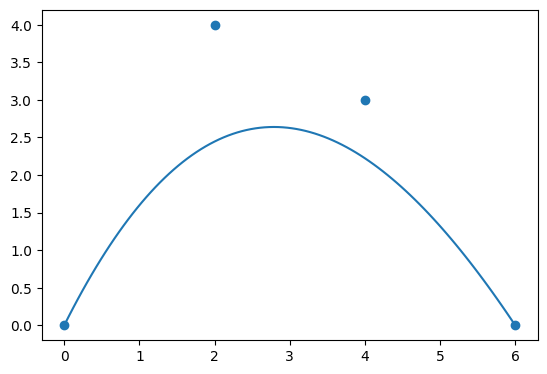

In [14]:
plt.plot(curve[:,0], curve[:,1])
plt.scatter(control_points[:,0], control_points[:,1])
plt.gca().set_aspect('equal', 'box')
plt.show()

## Lerp / De Casteljau’s Algorithm

In [15]:
def lerp(A, B, t):
    return (1 - t) * A + t * B

In a Bezier curve, you can think of the entire path as a series of nested lerps. By lerping between your control points, and then lerping between those results, you eventually arrive at a single point on the curve.

This approach is numerically stable because it keeps the coordinates within the range of the original points. It's often used in shaders and animation engines because it's computationally cheap and produces perfectly predictable motion.

In [16]:
def de_casteljau(control_points, t):
    points = control_points.clone()

    while len(points) > 1:
        new_points = []
        for i in range(len(points) - 1):
            new_points.append(lerp(points[i], points[i+1], t))
        points = torch.stack(new_points)

    return points[0]

This approach provides a clear geometric interpretation:For $t=0.5$, you find the midpoints of every segment in the control polygon.You connect those midpoints to form a new, smaller polygon.You repeat the process until you're left with a single point.

The final point $P(t)$ lies exactly on the Bezier curve. While the loop structure is slightly slower than a direct matrix multiplication for low-degree curves, it's the standard for subdivision and rendering because of its robustness.

In [17]:
curve = []

In [18]:
for t in t_vals:
    curve.append(de_casteljau(control_points, t))

In [19]:
curve = torch.stack(curve)

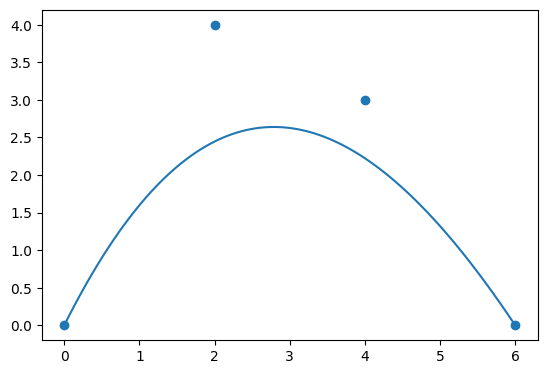

In [20]:
plt.plot(curve[:,0], curve[:,1])
plt.scatter(control_points[:,0], control_points[:,1])
plt.gca().set_aspect('equal', 'box')
plt.show()

## Matrix Bézier Form

Bézier form will look very familiar, because it uses the exact same structure as the Hermite curve you already coded.

The general structure stays

P(t) = T · M · G

Same three components. Only the basis matrix changes.

T is the parameter power vector

G is the geometry matrix built from control points

Now the Bézier basis matrix:
This matrix encodes the Bernstein polynomials for cubic Bézier curves.

Both are specific coordinate representations of the same four-dimensional vector space of cubic polynomials. Any cubic curve $P(t)$ in a Euclidean space can be expressed as a linear combination of the power basis $\{t^3, t^2, t, 1\}$. The matrix $M$ functions as a linear transformation that maps the geometric constraints in $G$ to the algebraic coefficients of this power basis.

### The Principle of Basis Equivalence

In the study of CAD and computer graphics, this is viewed as a change of basis within the polynomial space $P_3$. While the power basis is mathematically simple, it's geometrically unintuitive. The Hermite and Bézier forms provide "interpolatory" and "approximation" bases that offer direct control over the curve’s shape through physical parameters.

The general matrix form $P(t) = T \cdot M \cdot G$ remains constant because the underlying problem is always to find the four unknown vector coefficients $(a, b, c, d)$ for the equation $P(t) = at^3 + bt^2 + ct + d$.

### Linear Mapping of Constraints

The derivation of $M$ depends on the chosen boundary conditions. In the Hermite case, the matrix is derived by satisfying constraints on the position and first derivative at the interval endpoints $t=0$ and $t=1$. For the Bézier form, the matrix is derived from the Bernstein basis polynomials:

$$B_{i,n}(t) = \binom{n}{i} t^i (1-t)^{n-i}$$

Expanding these polynomials for $n=3$ yields the coefficients found in the $4 \times 4$ Bézier basis matrix. Because the mapping from Bézier control points to Hermite tangents is a linear operation, one form can be transformed into the other via a simple matrix multiplication. Specifically, for a cubic curve, the tangents are defined by the forward and backward differences of the control points: $T_0 = 3(P_1 - P_0)$ and $T_1 = 3(P_3 - P_2)$.

### Geometric Continuity

From an academic perspective, the choice between these matrices is a matter of interface, not capability. The Hermite form is preferred when matching derivatives at the joints of composite curves is the priority. The Bézier form is preferred for its convex hull property, which ensures the curve never strays outside the boundary defined by its control points. Since both methods ultimately solve for the same cubic polynomial, the computational machinery required to evaluate them is identical.

In [21]:
# Control points
P0 = torch.tensor([0.0, 0.0])
P1 = torch.tensor([2.0, 4.0])
P2 = torch.tensor([4.0, 3.0])
P3 = torch.tensor([6.0, 0.0])

In [22]:
# Geometry matrix (4x2)
G = torch.stack([P0, P1, P2, P3])

In [23]:
# Bezier basis matrix
M = torch.tensor([
    [-1.,  3., -3.,  1.],
    [ 3., -6.,  3.,  0.],
    [-3.,  3.,  0.,  0.],
    [ 1.,  0.,  0.,  0.]
])

In [24]:
curve_points = []

In [25]:
for t in t_vals:
    T = torch.tensor([t**3, t**2, t, 1.0])
    point = T @ M @ G
    curve_points.append(point)

In [26]:
curve = torch.stack(curve_points)

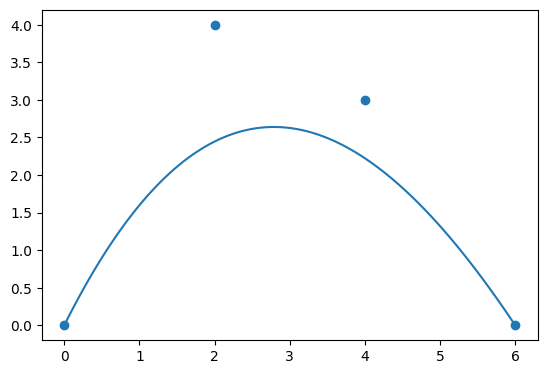

In [ ]:
plt.plot(curve[:,0], curve[:,1])
plt.scatter(G[:,0], G[:,1])
plt.gca().set_aspect('equal', 'box')
plt.show()